In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('Titanic-Dataset.csv.xls')

In [13]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
from sklearn.impute import SimpleImputer

In [16]:
num_imputer = SimpleImputer(strategy="median")
df[['Age']] = num_imputer.fit_transform(df[['Age']])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[['Embarked', 'Cabin']] = cat_imputer.fit_transform(df[['Embarked', 'Cabin']])

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex'])
df['Embarked'] = label.fit_transform(df['Embarked'])

In [20]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,B96 B98,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,B96 B98,2
5,6,0,3,"Moran, Mr. James",1,28.0,0,0,330877,8.4583,B96 B98,1
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,2
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,B96 B98,2
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,0,2,347742,11.1333,B96 B98,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,1,0,237736,30.0708,B96 B98,0


In [21]:
df = df.drop(columns=["Name", "Ticket", "Cabin"])

In [22]:
x = df.drop('Survived' , axis=1)
y = df['Survived']

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train , x_test , y_train ,y_test = train_test_split(x, y, test_size=0.2 , random_state=42)

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
dtype: object


In [27]:
model = DecisionTreeClassifier()
model.fit(x_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_predict = model.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy = accuracy_score(y_test, y_predict)

print(accuracy)

0.7597765363128491


In [31]:
print(model.feature_importances_)

[0.2415921  0.10829219 0.2934934  0.12924469 0.03086725 0.00658196
 0.16815362 0.02177479]


In [32]:
for features , importance in zip(x.columns , model.feature_importances_):
    print(features , importance)

PassengerId 0.24159210042234813
Pclass 0.10829219192106568
Sex 0.2934933962113755
Age 0.12924469052740958
SibSp 0.030867251078693862
Parch 0.006581955089417774
Fare 0.16815361994902578
Embarked 0.02177479480066361


<function matplotlib.pyplot.show(close=None, block=None)>

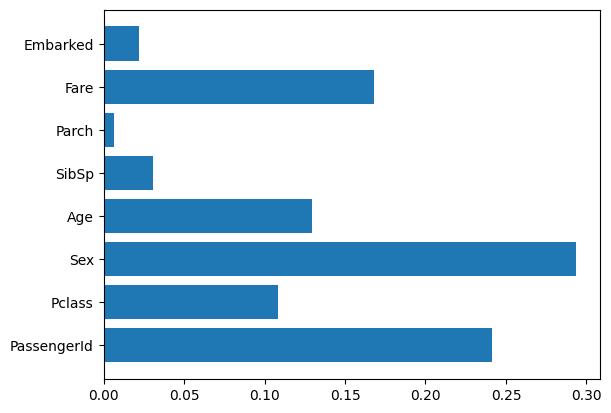

In [33]:
plt.barh(x.columns , model.feature_importances_)
plt.show

In [34]:
from sklearn.tree import plot_tree

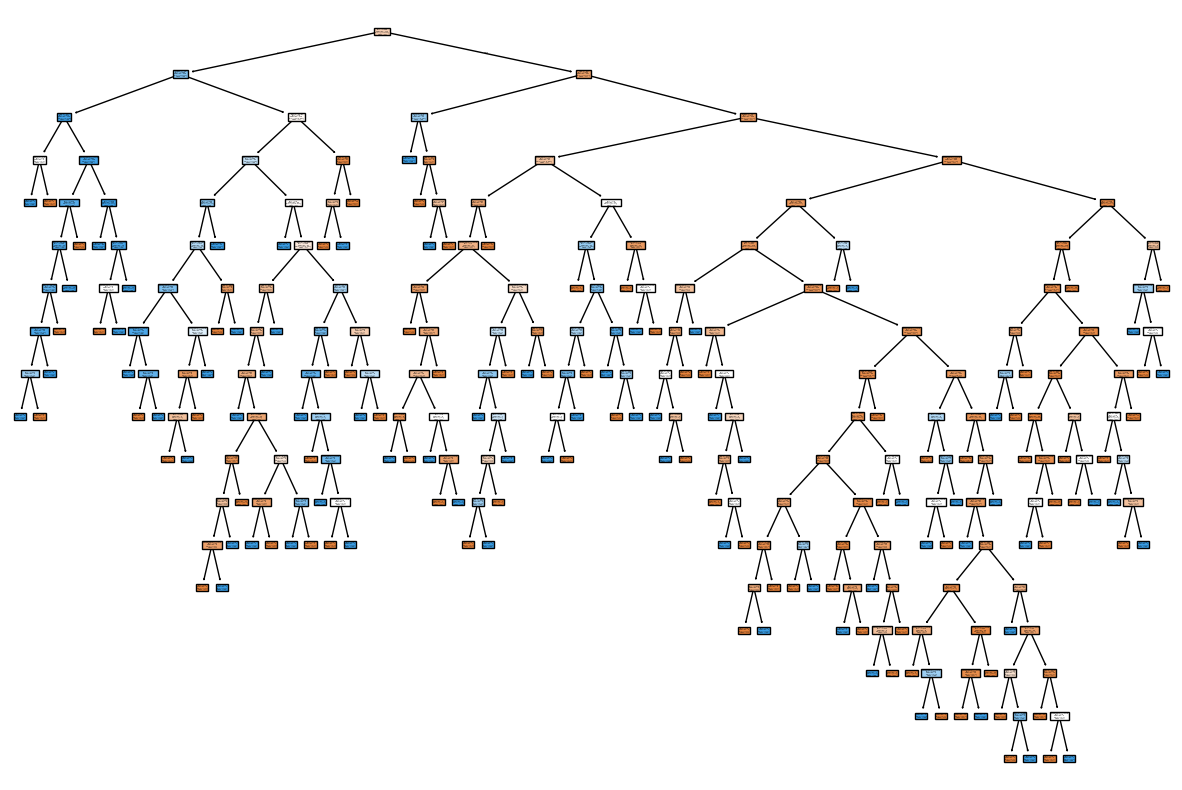

In [35]:
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=x.columns,class_names=["No", "Yes"],filled=True)

plt.show()

In [36]:
model = DecisionTreeClassifier(max_depth=3)

In [37]:
model = DecisionTreeClassifier(criterion="gini")

In [38]:
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [39]:
model = DecisionTreeClassifier(criterion="entropy")

In [40]:
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [41]:
gini_model = DecisionTreeClassifier(criterion="gini")
gini_model.fit(x_train, y_train)
gini_predict = gini_model.predict(x_test)
gini_accuracy = accuracy_score(y_test, gini_predict)
print(gini_accuracy)
entropy_predict = model.predict(x_test)
entropy_accuracy = accuracy_score(y_test, entropy_predict)
print(entropy_accuracy)

0.7486033519553073
0.7430167597765364


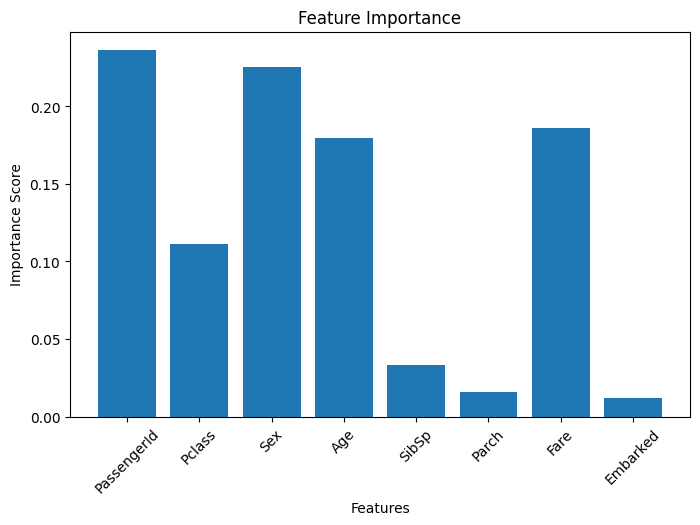

In [42]:
importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(x.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [43]:
results = {
    "Logistic Regression": 0.73,
    "Decision Tree Entropy": 0.748,
    "Decision Tree Gini": 0.754
}

print(results)

{'Logistic Regression': 0.73, 'Decision Tree Entropy': 0.748, 'Decision Tree Gini': 0.754}


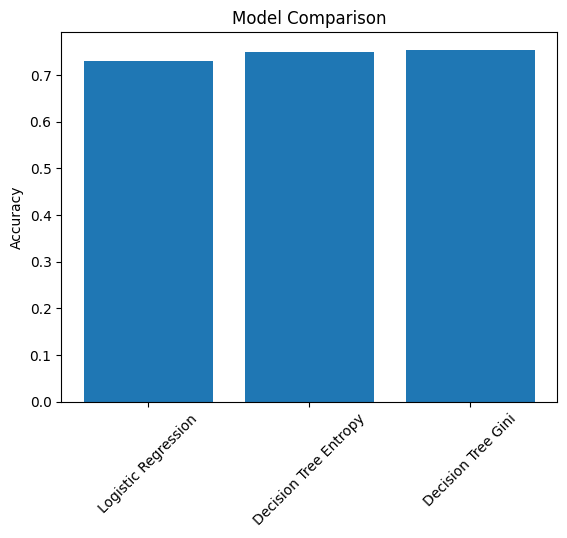

In [44]:
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

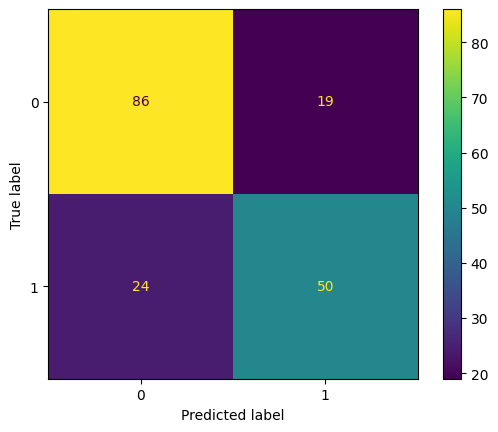

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict)
plt.show()

In [47]:
import seaborn as sns

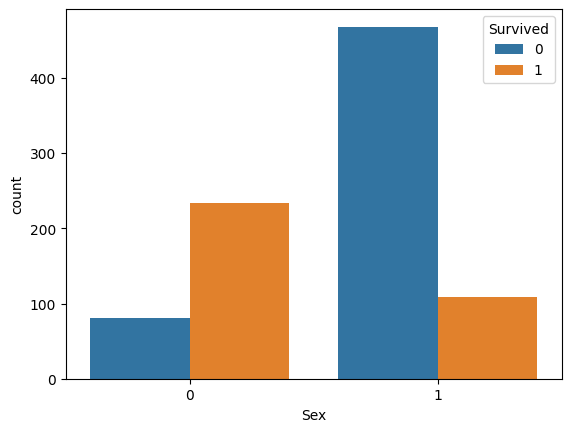

In [48]:
sns.countplot(x="Sex",hue="Survived",data=df)
plt.show()

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model = RandomForestClassifier(n_estimators=100 , random_state=42)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
rf_predict = rf_model.predict(x_test)

In [54]:
rf_accuracy = accuracy_score( y_test , rf_predict)

In [55]:
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8268156424581006


In [56]:
print("Decision Tree Gini Accuracy:", gini_accuracy)
print("Decision Tree Entropy Accuracy:", entropy_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Decision Tree Gini Accuracy: 0.7486033519553073
Decision Tree Entropy Accuracy: 0.7430167597765364
Random Forest Accuracy: 0.8268156424581006


In [57]:
results = {
    "Decision Tree Gini Accuracy": 0.7541,
    "Decision Tree Entropy Accuracy": 0.7486,
    "Random Forest Accuracy": 0.8268,
}

print(results)

{'Decision Tree Gini Accuracy': 0.7541, 'Decision Tree Entropy Accuracy': 0.7486, 'Random Forest Accuracy': 0.8268}


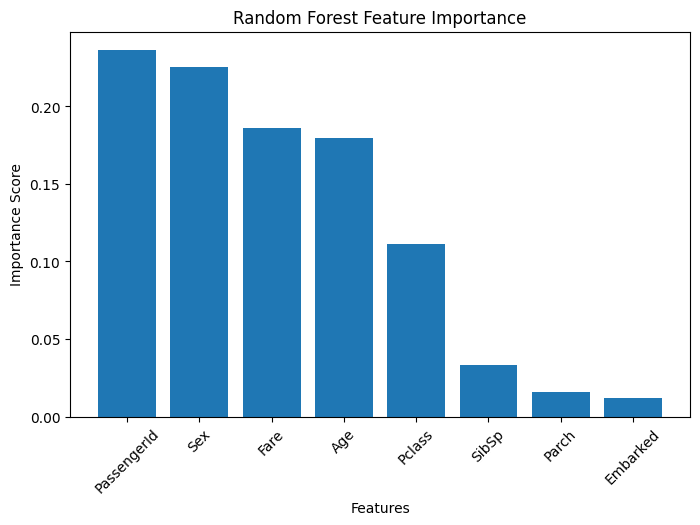

In [58]:
feature_importance = pd.DataFrame({ "Feature": x.columns,"Importance": model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"],feature_importance["Importance"])

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.savefig("feature_importance_random_forest.png", bbox_inches="tight")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

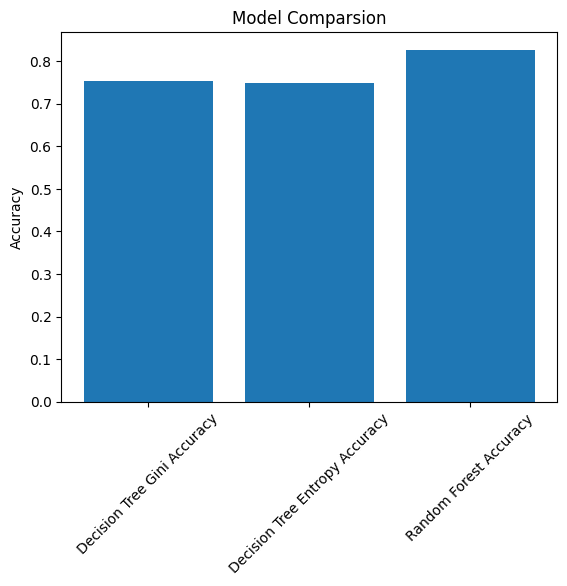

In [59]:
plt.bar(results.keys() , results.values())
plt.title("Model Comparsion")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show

In [60]:
from sklearn.metrics import confusion_matrix

In [61]:
cm = confusion_matrix(y_test , rf_predict)

In [62]:
print(cm)

[[93 12]
 [19 55]]


In [63]:
print("testing row:" , len(x_test))

testing row: 179


In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

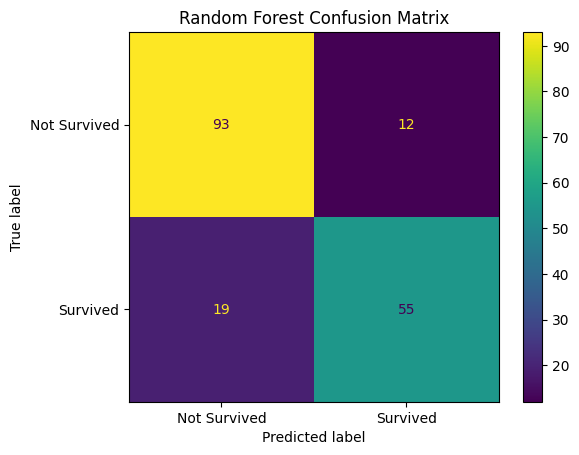

In [65]:
import os

ConfusionMatrixDisplay.from_predictions(y_test , rf_predict , display_labels=["Not Survived", "Survived"])
plt.title("Random Forest Confusion Matrix")
os.makedirs("images", exist_ok=True)
plt.savefig("images/confusion_matrix_random_forest.png", bbox_inches="tight")
plt.show()

In [66]:
from sklearn.metrics import classification_report

In [67]:
print(classification_report(y_test , rf_predict , target_names=["Not Survived" , "Survived"]))

              precision    recall  f1-score   support

Not Survived       0.83      0.89      0.86       105
    Survived       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [68]:
model_1 = RandomForestClassifier(n_estimators=100,random_state=42)
model_1.fit(x_train, y_train)
pred_1 = model_1.predict(x_test)
acc_1 = accuracy_score(y_test, pred_1)
print("Model 1 Accuracy:", acc_1)

Model 1 Accuracy: 0.8268156424581006


In [69]:
model_2 = RandomForestClassifier(n_estimators=200,max_depth=5,random_state=42)
model_2.fit(x_train, y_train)
pred_2 = model_2.predict(x_test)
acc_2 = accuracy_score(y_test, pred_2)
print("Model 2 Accuracy:", acc_2)

Model 2 Accuracy: 0.8100558659217877


In [70]:
model_3 = RandomForestClassifier(n_estimators=300,max_depth=7,min_samples_split=5,min_samples_leaf=2,random_state=42)
model_3.fit(x_train, y_train)
pred_3 = model_3.predict(x_test)
acc_3 = accuracy_score(y_test, pred_3)
print("Model 3 Accuracy:", acc_3)

Model 3 Accuracy: 0.8100558659217877


In [71]:
print("Default RF:", acc_1)
print("RF max_depth=5:", acc_2)
print("RF tuned:", acc_3)

Default RF: 0.8268156424581006
RF max_depth=5: 0.8100558659217877
RF tuned: 0.8100558659217877


In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()

In [74]:
x_train_scal = scaler.fit_transform(x_train)
x_test_scal = scaler.transform(x_test)

In [75]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scal , y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [76]:
knn_predict = knn_model.predict(x_test_scal)

In [77]:
from sklearn.metrics import accuracy_score

In [78]:
knn_accuracy = accuracy_score(y_test, knn_predict)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.8100558659217877


In [79]:
for k in [3, 5, 7, 9, 11, 15]:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(x_train_scal, y_train)
    knn_pred = knn_model.predict(x_test_scal)
    acc = accuracy_score(y_test, knn_pred)
    print("K =", k, "Accuracy =", acc)

K = 3 Accuracy = 0.8100558659217877
K = 5 Accuracy = 0.8100558659217877
K = 7 Accuracy = 0.7988826815642458
K = 9 Accuracy = 0.8044692737430168
K = 11 Accuracy = 0.8044692737430168
K = 15 Accuracy = 0.8212290502793296


In [80]:
knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(x_train_scal, y_train)
knn_pred = knn_model.predict(x_test_scal)
acc = accuracy_score(y_test, knn_pred)
print("KNN best accuracy : " , acc)

KNN best accuracy :  0.8212290502793296


In [81]:
from sklearn.metrics import confusion_matrix, classification_report
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

KNN Confusion Matrix:
[[93 12]
 [20 54]]


In [82]:
print("KNN Classification Report:")
print(classification_report(y_test, knn_pred))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [83]:
from sklearn.naive_bayes import GaussianNB

In [84]:
nb_model = GaussianNB()

In [85]:
nb_model.fit(x_train , y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[444.,268.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.62,0.38]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.582e-05
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['PassengerId','Pclass','Sex',...,'Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[444.25, 2.54, 0.86,..., 0.33, 22.63, 1.66], [454.83, 1.99, 0.32,..., 0.46, 49.07, 1.41]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[68008.31, 0.54, 0.12,..., 0.66, 1045.05, 0.48], [62120.67, 0.73, 0.22,..., 0.55, 4998.05, 0.75]]"


In [86]:
nb_predict = nb_model.predict(x_test)

In [87]:
nb_acc = accuracy_score(y_test , nb_predict)
print("NB accuracy: " , nb_acc)

NB accuracy:  0.776536312849162


In [88]:
from sklearn.svm import SVC

In [89]:
svm_model = SVC(kernel="rbf" , random_state=42)

In [90]:
svm_model.fit(x_train_scal , y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [91]:
svm_predict = svm_model.predict(x_test_scal)

In [92]:
svm_acc = accuracy_score(y_test , svm_predict)
print("SVM accuracy:" , svm_acc)

SVM accuracy: 0.8156424581005587


In [93]:
kernels = ["linear", "rbf", "poly", "sigmoid"]

for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(x_train_scal, y_train)
    svm_pred = svm_model.predict(x_test_scal)
    acc = accuracy_score(y_test, svm_pred)
    print(kernel, "SVM Accuracy:", acc)

linear SVM Accuracy: 0.7821229050279329
rbf SVM Accuracy: 0.8156424581005587
poly SVM Accuracy: 0.8044692737430168
sigmoid SVM Accuracy: 0.7374301675977654


In [94]:
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree Gini",
        "Decision Tree Entropy",
        "Naive Bayes",
        "KNN",
        "SVM RBF",
        "Random Forest"
    ],
    "Accuracy": [
        0.7541,
        0.7486,
        0.7765,
        0.8212,
        0.8156,
        0.8268
    ]
})

model_results = model_results.sort_values(by="Accuracy",ascending=False)

print(model_results)

                   Model  Accuracy
5          Random Forest    0.8268
3                    KNN    0.8212
4                SVM RBF    0.8156
2            Naive Bayes    0.7765
0     Decision Tree Gini    0.7541
1  Decision Tree Entropy    0.7486


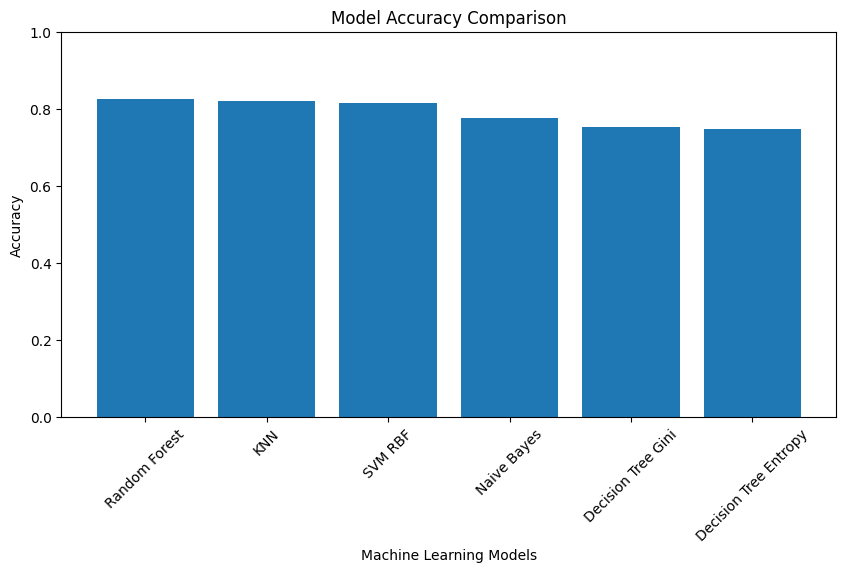

In [95]:
plt.figure(figsize=(10,5))

plt.bar(model_results["Model"],model_results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.savefig("model_comparsion.png", bbox_inches="tight")
plt.show()

In [96]:
rf_prob = model.predict_proba(x_test)[: , 1]

In [97]:
from sklearn.metrics import roc_auc_score

In [98]:
auc_score = roc_auc_score(y_test , rf_prob)
print("ROC-AUC Score:" , auc_score)

ROC-AUC Score: 0.733075933075933


In [100]:
from sklearn.model_selection import cross_val_score

In [101]:
score = cross_val_score(rf_model ,x ,y ,cv=5 , scoring="accuracy")

In [102]:
print(score)

[0.70949721 0.79213483 0.86516854 0.82022472 0.84269663]


In [106]:
print("Average Accuracy:" , score.mean())

Average Accuracy: 0.8059443851610067


In [108]:
rf = RandomForestClassifier(random_state=42)

In [111]:
from sklearn.model_selection import GridSearchCV

In [112]:
param_grid = {"n_estimators": [50, 100, 200],"max_depth": [None, 5, 10],"min_samples_split": [2, 5],"min_samples_leaf": [1, 2] }

In [113]:
grid_search = GridSearchCV(estimator=rf , param_grid=param_grid , cv=5 , scoring="accuracy" , n_jobs=-1 )

In [115]:
grid_search.fit(x,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [116]:
print("Best parameters:" , grid_search.best_params_)
print("Best CV Acuuracy:" , grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Acuuracy: 0.8160379135019772


In [118]:
best_rf_model = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=50,
    random_state=42
    )

best_rf_model.fit(x_train, y_train)
best_rf_pred = best_rf_model.predict(x_test)
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
print("Tuned Random Forest Test Accuracy:", best_rf_accuracy)

Tuned Random Forest Test Accuracy: 0.7988826815642458


In [119]:
from sklearn.model_selection import RandomizedSearchCV

In [121]:
param_dist = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4] 
    }

In [124]:
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
    )

In [126]:
random_search.fit(x,y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for 

In [127]:
print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}
Best CV Accuracy: 0.8249262444291006


In [128]:
random_best_rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=4,
    max_depth=15,
    random_state=42
)

random_best_rf.fit(x_train, y_train)

random_best_pred = random_best_rf.predict(x_test)

random_best_accuracy = accuracy_score(y_test, random_best_pred)

print("RandomizedSearchCV Tuned Test Accuracy:", random_best_accuracy)

RandomizedSearchCV Tuned Test Accuracy: 0.8156424581005587


In [129]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])

knn_pipeline.fit(x_train, y_train)
knn_pipeline_pred = knn_pipeline.predict(x_test)
knn_pipeline_accuracy = accuracy_score(y_test, knn_pipeline_pred)
print("KNN Pipeline Accuracy:", knn_pipeline_accuracy)

KNN Pipeline Accuracy: 0.8212290502793296


In [130]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[features]
y = df["Survived"]

numeric_features = ["Age", "Fare", "Pclass", "SibSp", "Parch"]
categorical_features = ["Sex", "Embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

x_train, x_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

full_pipeline.fit(x_train, y_train)

pipeline_pred = full_pipeline.predict(x_test)

pipeline_accuracy = accuracy_score(y_test, pipeline_pred)
print("Full Pipeline Accuracy:", pipeline_accuracy)

Full Pipeline Accuracy: 0.8100558659217877


In [131]:
import joblib

In [132]:
joblib.dump(full_pipeline , "titanic_full_pipeline.pkl")

['titanic_full_pipeline.pkl']

In [133]:
loaded_pipeline = joblib.load("titanic_full_pipeline.pkl")

In [134]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["male"],
    "Age": [22],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": ["S"]
})

prediction = loaded_pipeline.predict(new_passenger)

print("Prediction:", prediction)

Prediction: [0]


In [136]:
probability = loaded_pipeline.predict_proba(new_passenger)

print("Prediction Probability:", probability)

print("Prediction:", prediction[0])
print("Probability:", probability)

if prediction[0] == 1:
    print("Result: Survived")

else:
    print("Result: Not Survived")

Prediction Probability: [[0.62 0.38]]
Prediction: 0
Probability: [[0.62 0.38]]
Result: Not Survived


In [142]:
def predict_survival(Pclass, Sex, Age, SibSp, Parch, Fare, Embarked):
    passenger = pd.DataFrame({
        "Pclass": [Pclass],
        "Sex": [Sex],
        "Age": [Age],
        "SibSp": [SibSp],
        "Parch": [Parch],
        "Fare": [Fare],
        "Embarked": [Embarked]
    })

    prediction = loaded_pipeline.predict(passenger)[0]
    probability = loaded_pipeline.predict_proba(passenger)[0]

    result = "Survived" if prediction == 1 else "Not Survived"

    return {
        "Prediction": result,
        "Not Survived Probability": round(float(probability[0]), 2),
        "Survived Probability": round(float(probability[1]), 2)
    }

In [143]:
predict = predict_survival(3, "male", 22, 1, 0, 7.25, "S")
print(predict)

{'Prediction': 'Not Survived', 'Not Survived Probability': 0.62, 'Survived Probability': 0.38}
